# Ethereum Wallet Fraud Detection Using Machine Learning

## Objective
Analyze Ethereum wallet transaction behavior and detect suspicious/fraudulent wallets using machine learning techniques.

## Dataset
Ethereum Fraud Detection Dataset (https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset)

### ERC20 Features

- ERC20 refers to a standard used for Ethereum-based tokens.

- The dataset includes several ERC20-related features that describe token transfer behavior, including transfer amounts, token diversity, and interaction patterns.

- These features may help identify suspicious wallet activity associated with fraudulent behavior.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotx

pd.set_option("display.max_columns", None)
plt.style.use(matplotx.styles.github["dark"])


In [2]:
df = pd.read_csv('../data/raw/transaction_dataset.csv')

In [3]:
df

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.000000,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.00,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.000000,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.00,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.050000,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.00,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.000000,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.00,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.000000,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.00,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9836,9836,2175,0xff481ca14e6c16b79fc8ab299b4d2387ec8ecdd2,1,12635.10,631.39,58748.48,4,13,0,11,4,0.004082,12.000000,2.821060,0.465461,12.200000,9.166365,0.0,0.0,0.0,17,36.665461,36.673777,0.0,0.008316,2.0,1.337000e+00,0.000000e+00,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.00,1.337000e+00,0.668500,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,2.0,,GSENetwork
9837,9837,2176,0xff718805bb9199ebf024ab6acd333e603ad77c85,1,0.00,0.00,0.00,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,0.000000,0.000000,0.0,0.000000,1.0,1.337000e+01,0.000000e+00,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,13.37,1.337000e+01,13.370000,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,1.0,,Blockwell say NOTSAFU
9838,9838,2177,0xff8e6af02d41a576a0c82f7835535193e1a6bccc,1,2499.44,2189

In [4]:
df = df.drop(columns=["Unnamed: 0", "Index", "Address"])

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FLAG,9841.0,2.214206e-01,4.152241e-01,0.00,0.000000,0.000000e+00,0.000000,1.000000e+00
Avg min between sent tnx,9841.0,5.086879e+03,2.148655e+04,0.00,0.000000,1.734000e+01,565.470000,4.302877e+05
Avg min between received tnx,9841.0,8.004851e+03,2.308171e+04,0.00,0.000000,5.097700e+02,5480.390000,4.821755e+05
Time Diff between first and last (Mins),9841.0,2.183333e+05,3.229379e+05,0.00,316.930000,4.663703e+04,304070.980000,1.954861e+06
Sent tnx,9841.0,1.159317e+02,7.572264e+02,0.00,1.000000,3.000000e+00,11.000000,1.000000e+04
Received Tnx,9841.0,1.637009e+02,9.408366e+02,0.00,1.000000,4.000000e+00,27.000000,1.000000e+04
Number of Created Contracts,9841.0,3.729702e+00,1.414456e+02,0.00,0.000000,0.000000e+00,0.000000,9.995000e+03
Unique Received From Addresses,9841.0,3.036094e+01,2.986211e+02,0.00,1.000000,2.000000e+00,5.000000,9.999000e+03
Unique Sent To Addresses,9841.0,2.584016e+01,2.638204e+02,0.00,1.000000,2.000000e+00,3.000000,9.287000e+03
min value received,9841.0,4.384515e+01,3.259291e+02,0.00,0.001000,9.585600e-02,2.000000,1.000000e+04


In [6]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

ERC20 most sent token type             2697
ERC20_most_rec_token_type               871
ERC20 total ether sent                  829
ERC20 total Ether received              829
ERC20 uniq sent addr                    829
ERC20 uniq rec addr                     829
ERC20 uniq sent addr.1                  829
ERC20 total Ether sent contract         829
Total ERC20 tnxs                        829
ERC20 avg time between sent tnx         829
ERC20 uniq rec contract addr            829
ERC20 avg time between rec tnx          829
ERC20 avg time between rec 2 tnx        829
ERC20 max val rec                       829
ERC20 avg val rec                       829
ERC20 avg time between contract tnx     829
ERC20 min val rec                       829
ERC20 max val sent                      829
ERC20 min val sent                      829
ERC20 avg val sent                      829
ERC20 min val sent contract             829
ERC20 avg val sent contract             829
ERC20 max val sent contract     

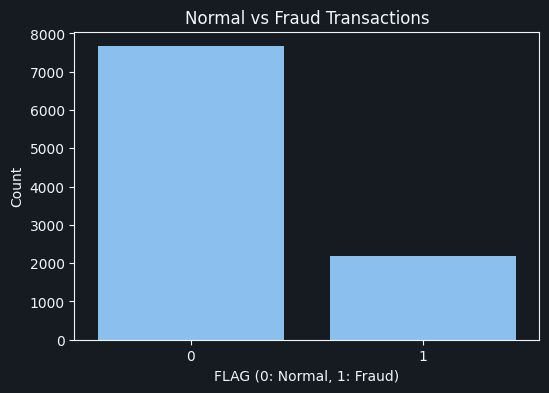

FLAG
0    77.857941
1    22.142059
Name: proportion, dtype: float64


In [7]:
df["FLAG"].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(x="FLAG", data=df)
plt.title("Normal vs Fraud Transactions")
plt.xlabel("FLAG (0: Normal, 1: Fraud)")
plt.ylabel("Count")
plt.show()

fraud_percentage = df["FLAG"].value_counts(normalize=True) * 100
print(fraud_percentage)


## Observation

The dataset is imbalanced, with significantly fewer fraud wallets compared to legitimate wallets.

This imbalance must be considered during model training and evaluation.

In [8]:
correlation = df.corr(numeric_only=True)["FLAG"].sort_values(ascending=False)

print(correlation)

FLAG                                                    1.000000
 ERC20 min val sent                                     0.025364
 ERC20 avg val sent                                     0.025044
 ERC20 max val sent                                     0.025038
 ERC20 total ether sent                                 0.024762
 ERC20 total Ether sent contract                        0.013514
 ERC20 min val rec                                      0.011163
 ERC20 uniq sent token name                             0.009249
 ERC20 avg val rec                                      0.007881
min val sent                                            0.006626
 ERC20 uniq sent addr.1                                -0.003047
total ether balance                                    -0.003229
 ERC20 max val rec                                     -0.004313
 ERC20 total Ether received                            -0.004475
min value sent to contract                             -0.007213
max val sent to contract 

### ERC20 Features

ERC20 refers to a standard used for Ethereum-based tokens.

The dataset includes several ERC20-related features that describe token transfer behavior, including transfer amounts, token diversity, and interaction patterns.

These features may help identify suspicious wallet activity associated with fraudulent behavior.

In [9]:
best_features = correlation[1:11]

<Axes: title={'center': 'Top 10 Features Correlated with Fraud (FLAG)'}, xlabel='Correlation Coefficient', ylabel='Feature'>

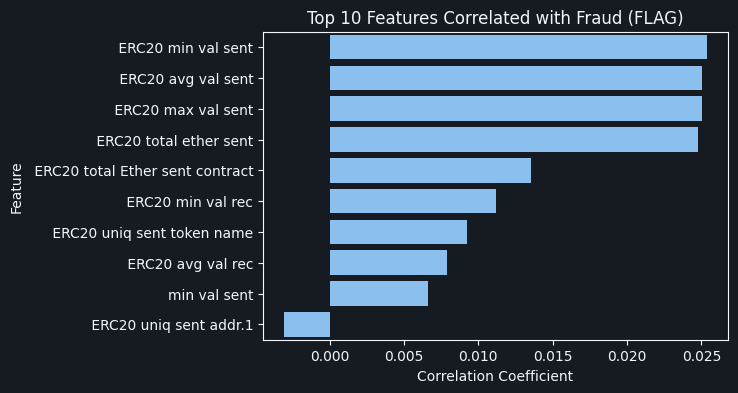

In [10]:
plt.figure(figsize=(6, 4))
plt.title("Top 10 Features Correlated with Fraud (FLAG)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
sns.barplot(x = best_features.values, 
            y=best_features.index
)  

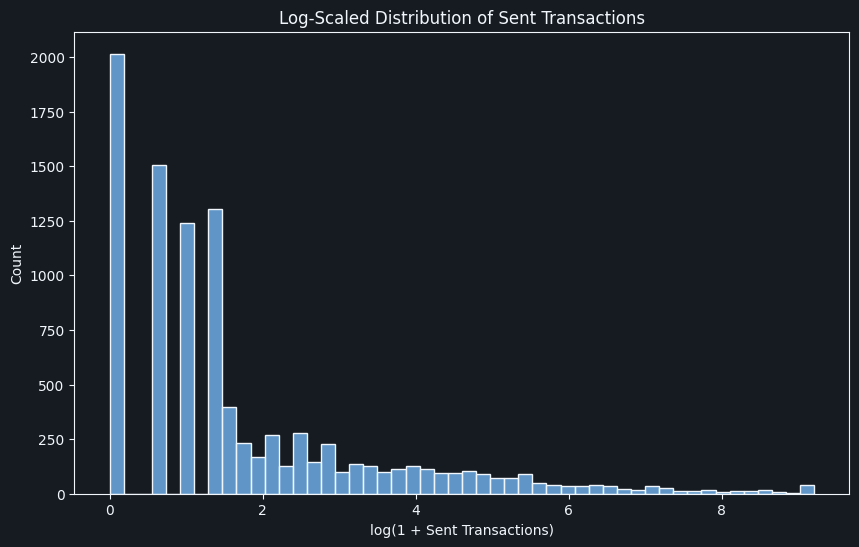

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(df["Sent tnx"]),
    bins=50
)

plt.title("Log-Scaled Distribution of Sent Transactions")
plt.xlabel("log(1 + Sent Transactions)")
plt.ylabel("Count")

plt.show()

This visualization shows the distribution of the number of transactions sent by Ethereum wallets.

The original `Sent tnx` feature was heavily right-skewed, meaning:

- Most wallets sent very few transactions
- A small number of wallets sent extremely large numbers of transactions

These outliers compressed the histogram and made the majority of the data difficult to visualize clearly.

To better interpret the histogram, we applied a logarithmic transformation using:

log(1 + Sent tnx)

### Key Insights

- Most wallets exhibit relatively low transaction activity
- A small number of wallets are extremely active
- The dataset contains significant outliers
- Wallet activity is not normally distributed

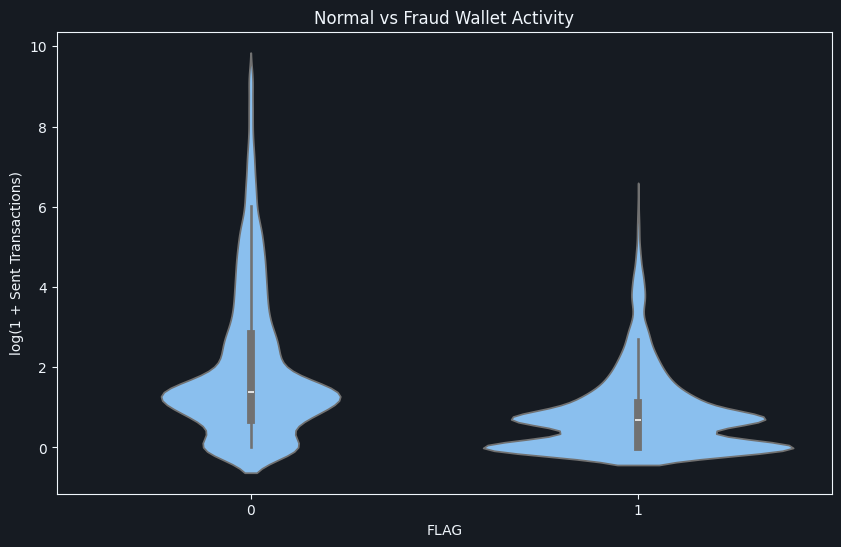

In [12]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x=df["FLAG"],
    y=np.log1p(df["Sent tnx"])
)

plt.title("Normal vs Fraud Wallet Activity")
plt.xlabel("FLAG")
plt.ylabel("log(1 + Sent Transactions)")

plt.show()

## Observation

- Normal wallets generally exhibit higher transaction activity compared to fraud wallets.

- The fraud wallets are more concentrated around lower transaction counts, while normal wallets show a wider range of activity.